In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('/kaggle/input/datasets/asananidhruv/saas-dataset/SaaS_Financial_Churn_Dataset.csv')


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Customer_ID                 150000 non-null  object 
 1   Industry                    150000 non-null  object 
 2   Company_Size                150000 non-null  object 
 3   Tenure_Months               150000 non-null  int64  
 4   Monthly_Charges             150000 non-null  float64
 5   Total_Users                 150000 non-null  int64  
 6   Integration_Count           150000 non-null  int64  
 7   Monthly_Logins              150000 non-null  int64  
 8   API_Utilization_Rate        150000 non-null  float64
 9   Premium_Feature_Usage       150000 non-null  int64  
 10  Support_Tickets_Raised      150000 non-null  int64  
 11  System_Error_Logs           150000 non-null  int64  
 12  Late_Payment_Count          150000 non-null  int64  
 13  Onboarding_Com

In [4]:
df.describe()


,Tenure_Months,Monthly_Charges,Total_Users,Integration_Count,Monthly_Logins,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count,Onboarding_Completion_Rate,NPS_Score,Admin_Logins,Reports_Downloaded,Mobile_App_Usage,Usage_Drop_Last_30_Days,Churn
count,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,35.90956,2526.878965,251.922247,3.494533,149.765847,49.898801,0.399933,2.000720,1.494227,0.500093,54.916938,5.507673,25.054093,9.492013,0.500793,0.199367,0.277467
std,20.42925,1427.159422,142.995486,2.292316,86.284241,28.789602,0.489886,1.412421,1.222147,0.705382,25.978571,2.875294,14.135378,5.756973,0.500001,0.399526,0.447750
min,1.00000,50.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,18.00000,1291.352500,128.000000,1.000000,75.000000,25.120000,0.000000,1.000000,1.000000,0.000000,32.380000,3.000000,13.000000,5.000000,0.000000,0.000000,0.000000
50%,36.00000,2526.720000,252.000000,3.000000,150.000000,49.820000,0.000000,2.000000,1.000000,0.000000,54.910000,6.000000,25.000000,9.000000,1.000000,0.000000,0.000000
75%,53.00000,3760.232500,376.000000,5.000000,224.000000,74.760000,1.000000,3.000000,2.000000,1.000000,77.410000,8.000000,37.000000,14.000000,1.000000,0.000000,1.000000
max,71.00000,4999.990000,499.000000,7.000000,299.000000,100.000000,1.000000,12.000000,9.000000,6.000000,100.000000,10.000000,49.000000,19.000000,1.000000,1.000000,1.000000


In [5]:
df.drop(columns = ['Customer_ID','Integration_Count', 'Monthly_Logins', 'Onboarding_Completion_Rate','Admin_Logins','Reports_Downloaded', 'Mobile_App_Usage'], inplace = True)


In [6]:
print(df['Industry'].unique())
print(df['Company_Size'].unique())


['Retail' 'Healthcare' 'Technology' 'Manufacturing' 'Finance']
['Startup' 'SMB' 'Enterprise']


In [7]:
df.shape


(150000, 13)

In [8]:
df['Churn'].unique()


array([0, 1])

In [9]:
df.head()

,Industry,Company_Size,Tenure_Months,Monthly_Charges,Total_Users,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count,NPS_Score,Usage_Drop_Last_30_Days,Churn
0,Retail,Startup,27,3242.22,419,73.26,1,1,2,1,7,0,0
1,Healthcare,SMB,46,3411.10,260,25.97,1,4,1,0,4,1,0
2,Technology,Enterprise,43,4671.74,368,15.27,1,2,2,1,9,0,0
3,Manufacturing,Enterprise,45,2996.55,197,72.92,1,2,2,0,2,0,0
4,Finance,Enterprise,30,305.92,68,46.48,1,2,0,1,9,0,0


In [10]:
X = df.iloc[:,:10]
X

,Industry,Company_Size,Tenure_Months,Monthly_Charges,Total_Users,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count
0,Retail,Startup,27,3242.22,419,73.26,1,1,2,1
1,Healthcare,SMB,46,3411.10,260,25.97,1,4,1,0
2,Technology,Enterprise,43,4671.74,368,15.27,1,2,2,1
3,Manufacturing,Enterprise,45,2996.55,197,72.92,1,2,2,0
4,Finance,Enterprise,30,305.92,68,46.48,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...
149995,Finance,Startup,55,2080.52,355,95.48,1,4,1,0
149996,Finance,SMB,47,2939.62,419,8.58,0,0,2,1
149997,Finance,SMB,65,1466.90,467,62.19,0,6,1,1
149998,Finance,Startup,1,173.72,23,81.49,1,2,1,0


In [11]:
y = df.iloc[:,12:13]
y

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
149995,0
149996,1
149997,0
149998,0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
ohe = OneHotEncoder(sparse_output = False).set_output(transform="pandas")

In [14]:
encoded_data_train = ohe.fit_transform(X_train[['Industry']])

In [15]:
encoded_data_test= ohe.fit_transform(X_test[['Industry']])

In [16]:
X_train = pd.concat([X_train.drop(columns = "Industry"), encoded_data_train], axis =1)

In [17]:
X_test = pd.concat([X_test.drop(columns = "Industry"), encoded_data_test], axis =1)

In [18]:
df["Company_Size"].unique()

array(['Startup', 'SMB', 'Enterprise'], dtype=object)

In [19]:
company_size_order = ['Startup', 'SMB', "Enterprise"]

In [20]:
oe = OrdinalEncoder(
    categories= [company_size_order],
)

In [21]:
X_train[['Company_Size']] = oe.fit_transform(X_train[["Company_Size"]])

In [22]:
X_test[['Company_Size']] = oe.fit_transform(X_test[["Company_Size"]])

In [23]:
X_train

,Company_Size,Tenure_Months,Monthly_Charges,Total_Users,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count,Industry_Finance,Industry_Healthcare,Industry_Manufacturing,Industry_Retail,Industry_Technology
104025,1.0,41,2420.98,105,19.76,1,2,1,0,1.0,0.0,0.0,0.0,0.0
5415,0.0,32,1441.35,406,9.47,0,4,0,0,0.0,0.0,0.0,1.0,0.0
75612,1.0,13,4642.33,257,1.75,1,4,2,0,1.0,0.0,0.0,0.0,0.0
138169,1.0,71,2006.61,313,42.74,0,2,1,0,0.0,0.0,0.0,0.0,1.0
87184,2.0,29,4439.88,65,64.82,0,1,2,1,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,1.0,38,4580.36,26,81.15,0,1,2,1,1.0,0.0,0.0,0.0,0.0
103694,2.0,70,2639.74,356,13.09,0,2,1,1,0.0,0.0,1.0,0.0,0.0
131932,2.0,64,3554.49,267,59.49,0,0,1,0,0.0,0.0,0.0,1.0,0.0
146867,1.0,7,4946.80,471,0.18,1,2,4,0,0.0,0.0,0.0,0.0,1.0


In [24]:
scaler = StandardScaler().set_output(transform = "pandas")

In [25]:
X_train[["Tenure_Months", "Monthly_Charges", "Total_Users","API_Utilization_Rate"]] = scaler.fit_transform(X_train[["Tenure_Months", "Monthly_Charges", "Total_Users","API_Utilization_Rate"]])

In [26]:
X_test[["Tenure_Months", "Monthly_Charges", "Total_Users", "API_Utilization_Rate"]] = scaler.transform(X_test[["Tenure_Months", "Monthly_Charges", "Total_Users","API_Utilization_Rate"]])

In [27]:
X_train

,Company_Size,Tenure_Months,Monthly_Charges,Total_Users,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count,Industry_Finance,Industry_Healthcare,Industry_Manufacturing,Industry_Retail,Industry_Technology
104025,1.0,0.247111,-0.073700,-1.027925,-1.050140,1,2,1,0,1.0,0.0,0.0,0.0,0.0
5415,0.0,-0.192983,-0.760197,1.078620,-1.407736,0,4,0,0,0.0,0.0,0.0,1.0,0.0
75612,1.0,-1.122071,1.482961,0.035845,-1.676020,1,4,2,0,1.0,0.0,0.0,0.0,0.0
138169,1.0,1.714092,-0.364079,0.427761,-0.251543,0,2,1,0,0.0,0.0,0.0,0.0,1.0
87184,2.0,-0.339682,1.341089,-1.307864,0.515777,0,1,2,1,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,1.0,0.100413,1.439534,-1.580805,1.083274,0,1,2,1,1.0,0.0,0.0,0.0,0.0
103694,2.0,1.665193,0.079601,0.728695,-1.281934,0,2,1,1,0.0,0.0,1.0,0.0,0.0
131932,2.0,1.371797,0.720633,0.105830,0.330550,0,0,1,0,0.0,0.0,0.0,1.0,0.0
146867,1.0,-1.415468,1.696325,1.533522,-1.730580,1,2,4,0,0.0,0.0,0.0,0.0,1.0


In [28]:
X_test

,Company_Size,Tenure_Months,Monthly_Charges,Total_Users,API_Utilization_Rate,Premium_Feature_Usage,Support_Tickets_Raised,System_Error_Logs,Late_Payment_Count,Industry_Finance,Industry_Healthcare,Industry_Manufacturing,Industry_Retail,Industry_Technology
59770,1.0,0.638306,0.826281,0.840671,1.433225,1,4,0,0,1.0,0.0,0.0,0.0,0.0
21362,1.0,0.051513,-0.225592,-1.174893,0.677720,0,1,2,1,0.0,0.0,0.0,1.0,0.0
127324,1.0,-0.681977,-1.684221,0.329782,-1.230502,0,1,2,0,0.0,0.0,1.0,0.0,0.0
140509,1.0,0.491608,-0.715747,-0.684999,0.273557,1,0,1,1,1.0,0.0,0.0,0.0,0.0
144297,1.0,0.980602,-0.685999,0.819676,-0.722778,0,2,1,0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30430,1.0,-0.681977,1.449036,0.112829,1.672317,0,5,1,0,1.0,0.0,0.0,0.0,0.0
63244,0.0,-1.464367,-1.125439,1.036629,-1.119643,0,3,2,0,0.0,0.0,0.0,1.0,0.0
104970,2.0,1.714092,-0.463371,-0.789976,0.692316,0,6,1,0,0.0,0.0,0.0,0.0,1.0
53960,0.0,0.002614,0.192419,0.525739,-1.399743,0,1,3,1,0.0,0.0,0.0,1.0,0.0


<Axes: xlabel='Churn', ylabel='count'>

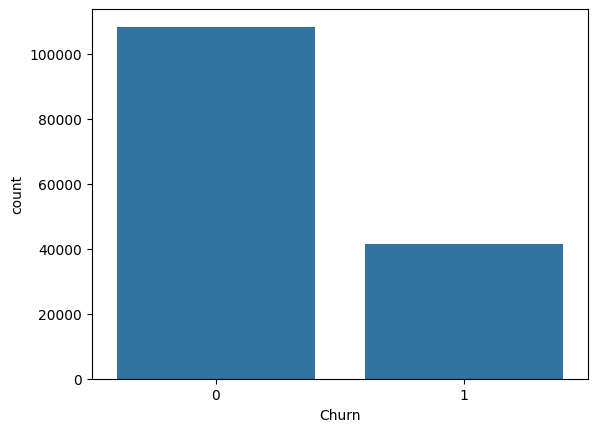

In [29]:
sns.countplot(data=df, x='Churn')

<Axes: xlabel='Churn', ylabel='Monthly_Charges'>

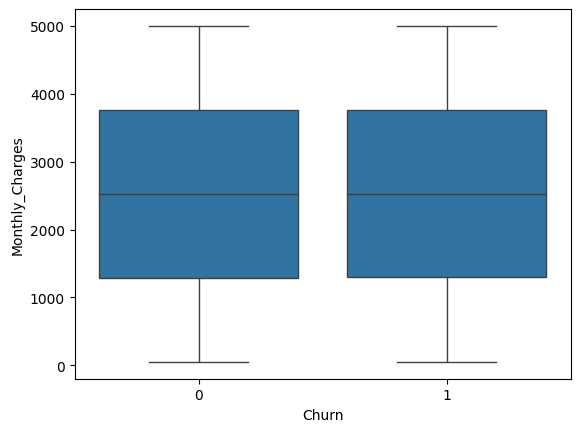

In [30]:
sns.boxplot(data=df, x='Churn', y='Monthly_Charges')

<Axes: xlabel='Company_Size', ylabel='Churn'>

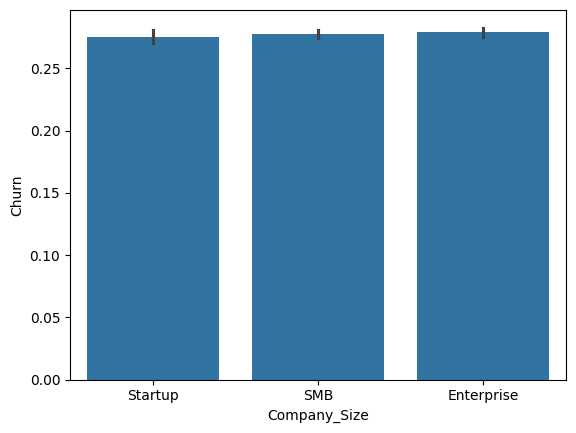

In [31]:
sns.barplot(data=df, x='Company_Size', y='Churn')

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [33]:
rf_model = RandomForestClassifier(random_state = 42)

In [34]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [35]:
rf_model_predictions = rf_model.predict(X_test)

In [36]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_model_predictions))
print("\nDetailed Report:\n", classification_report(y_test, rf_model_predictions))

Random Forest Accuracy: 0.7131

Detailed Report:
               precision    recall  f1-score   support

           0       0.72      0.97      0.83     21676
           1       0.34      0.04      0.07      8324

    accuracy                           0.71     30000
   macro avg       0.53      0.50      0.45     30000
weighted avg       0.62      0.71      0.62     30000



In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [38]:
xgbost = XGBClassifier(random_state = 42)

In [39]:
xgbost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
xgb_predict = xgbost.predict(X_test)

In [41]:
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_predict))

print("\nDetailed Report:\n", classification_report(y_test, xgb_predict))

XGBoost Accuracy: 0.7184333333333334

Detailed Report:
               precision    recall  f1-score   support

           0       0.73      0.98      0.83     21676
           1       0.41      0.03      0.06      8324

    accuracy                           0.72     30000
   macro avg       0.57      0.51      0.45     30000
weighted avg       0.64      0.72      0.62     30000



/tmp/ipykernel_16/4225480770.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_diary, x='Importance_Score', y='Feature', palette='viridis')


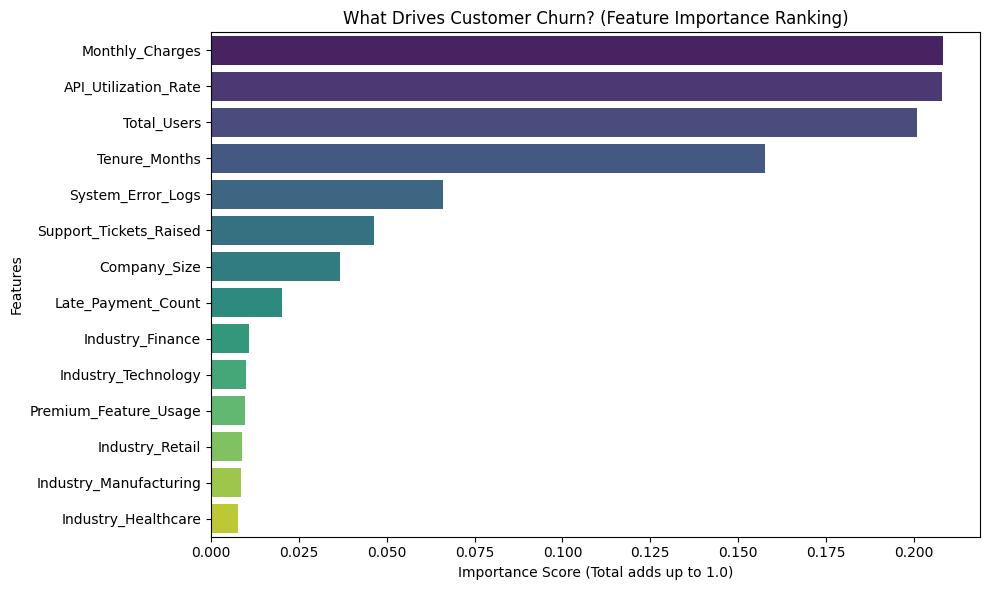

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the raw scores directly from the model's "brain"
# (If you want to check XGBoost instead, just change rf_model to xgb_model)
importances = rf_model.feature_importances_

# 2. Get the exact column names from your training data
feature_names = X_train.columns

# 3. Create a clean Pandas DataFrame to hold the results
feature_diary = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

# 4. Sort them from highest score (most important) to lowest
feature_diary = feature_diary.sort_values(by='Importance_Score', ascending=False)

# 5. Plot the ranking!
plt.figure(figsize=(10, 6))
# We put the features on the y-axis so the text is easy to read
sns.barplot(data=feature_diary, x='Importance_Score', y='Feature', palette='viridis')

plt.title('What Drives Customer Churn? (Feature Importance Ranking)')
plt.xlabel('Importance Score (Total adds up to 1.0)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [43]:
# print("Enter the data to for the prediction")


# try:
#     monthly_charges = int(input("Enter the charges paid in a month : "))
#     api_utilization_rate = int(input("Enter your api usage : "))
#     users = int(input("Enter the users till now : "))
#     tenure = int(input("Enter the tenure in months : "))
#     system_errors = int(input("Enter the number of error logs : "))
#     support_tickets = int(input("Enter the support tickets raised : "))
#     company_size = input("Company Size [Startup, SMB, Enterprise] : ")
#     late_payment = int(input("Enter the late pyment counts"))
#     industry = input("Enter the industry[Finance, Healthcare, Manufacturing, Retail, Technology]")
#     premium = int(input("Enter the premium feature usage : (0=no and 1 = yes)"))


#     custom_data = pd.DataFrame([{
#         'Monthly_Charges' : monthly_charges,
#         "API_Utilization_Rate" : api_utilization_rate,
#         "Total_Users" : users,
#         'Tenure_Months' : tenure,
#         "System_Error_Logs" : system_errors,
#         "Support_Tickets_Raised" : support_tickets,
#         "Company_Size" : company_size,
#         "Late_Payment_Count" : late_payment,
#         "Industry" : industry,
#         "Premium_Feature_Usage" : premium,
        
#     }])
#     size_mapping = {'Startup': 0, 'SMB': 1, 'Enterprise': 2}
#     custom_data['Company_Size'] = custom_data['Company_Size'].map(size_mapping)

#     # 3. Handle Industry (One-Hot Encoding)
#     industry_columns = [
#         'Industry_Finance', 
#         'Industry_Healthcare', 
#         'Industry_Manufacturing', 
#         'Industry_Retail', 
#         'Industry_Technology'
#     ]
#     for col in industry_columns:
#         custom_data[col] = 0
        
#     selected_industry = f"Industry_{industry}"
#     if selected_industry in custom_data.columns:
#         custom_data[selected_industry] = 1
        
#     custom_data = custom_data.drop('Industry', axis=1)

#     # ---------------------------------------------------------
#     # 4. APPLY STANDARD SCALER
#     # ---------------------------------------------------------
#     # Define the columns that need scaling exactly as you did in training
#     cols_to_scale = ["Tenure_Months", "Monthly_Charges", "Total_Users", "API_Utilization_Rate"]
    
#     # Note: We use .transform(), NOT .fit_transform()!
#     # Make sure 'scaler' is the actual variable name of your StandardScaler from earlier in your notebook.
#     custom_data[cols_to_scale] = scaler.transform(custom_data[cols_to_scale])

#     # ---------------------------------------------------------
#     # PREDICTION
#     # ---------------------------------------------------------
#     # Force the column order to match
#     custom_data = custom_data[xgbost.feature_names_in_]
    
#     # Predict
#     custom_prediction = xgbost.predict(custom_data)[0]
    
#     print("\n--- RESULTS ---")
#     if custom_prediction == 1:
#         print("🚨 Prediction: This customer WILL CHURN.")
#     else:
#         print("✅ Prediction: This customer is SAFE.")

# except ValueError as e:
#     print(f"\n❌ Error: Please check your inputs. Detail: {e}")